In [8]:
import pandas as pd

train_df = pd.read_csv('data/fashion-mnist_train.csv')
test_df = pd.read_csv('data/fashion-mnist_test.csv')

In [9]:
print('训练集形状:', train_df.shape)
print('测试集形状:', test_df.shape)

print('\n训练集前 5 行:')
display(train_df.head())


训练集形状: (60000, 785)
测试集形状: (10000, 785)

训练集前 5 行:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
print('训练集标签分布:')
print(train_df.iloc[:, 0].value_counts().sort_index())

print('\n测试集标签分布:')
print(test_df.iloc[:, 0].value_counts().sort_index())


训练集标签分布:
label
0    6000
1    6000
2    6000
3    6000
4    6000
5    6000
6    6000
7    6000
8    6000
9    6000
Name: count, dtype: int64

测试集标签分布:
label
0    1000
1    1000
2    1000
3    1000
4    1000
5    1000
6    1000
7    1000
8    1000
9    1000
Name: count, dtype: int64


In [11]:
X_train_raw = train_df.iloc[:, 1:].values
y_train_raw = train_df.iloc[:, 0].values

X_test_raw = test_df.iloc[:, 1:].values
y_test_raw = test_df.iloc[:, 0].values

X_train = X_train_raw.astype('float32') / 255.0
X_test = X_test_raw.astype('float32') / 255.0

# 3. 检查处理后的结果
print("训练集特征形状:", X_train.shape)   # 应该是 (60000, 784)
print("归一化后的最大值:", X_train.max()) # 应该是 1.0
print("归一化后的最小值:", X_train.min()) # 应该是 0.0

训练集特征形状: (60000, 784)
归一化后的最大值: 1.0
归一化后的最小值: 0.0


In [12]:
import numpy as np

def to_one_hot(labels, num_classes=10):
    """
    手动实现独热编码，不调用 sklearn
    """
    # 创建一个全 0 的矩阵，行数是样本数，列数是类别数 (10)
    one_hot = np.zeros((labels.shape[0], num_classes))
    # 在对应的位置填上 1
    # np.arange(labels.shape[0]) 代表选中每一行
    # labels 代表选中每一行对应的类别列
    one_hot[np.arange(labels.shape[0]), labels] = 1
    return one_hot

# 转换标签
y_train = to_one_hot(y_train_raw)
y_test = to_one_hot(y_test_raw)

print("原始标签样例 (前2个):", y_train_raw[:2])
print("独热编码后的结果 (前2个):\n", y_train[:2])

原始标签样例 (前2个): [2 9]
独热编码后的结果 (前2个):
 [[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [13]:
import numpy as np

class MyNeuralNetwork:
    def __init__(self, input_size=784, hidden_size=128, output_size=10):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        
        # 参数初始化
        self.W1 = np.random.randn(self.input_size, self.hidden_size) * np.sqrt(2.0 / self.input_size)
        self.b1 = np.zeros((1, self.hidden_size))
        self.W2 = np.random.randn(self.hidden_size, self.output_size) * np.sqrt(2.0 / self.hidden_size)
        self.b2 = np.zeros((1, self.output_size))
        
        # Adam 优化器变量
        self.m_W1, self.v_W1 = np.zeros_like(self.W1), np.zeros_like(self.W1)
        self.m_b1, self.v_b1 = np.zeros_like(self.b1), np.zeros_like(self.b1)
        self.m_W2, self.v_W2 = np.zeros_like(self.W2), np.zeros_like(self.W2)
        self.m_b2, self.v_b2 = np.zeros_like(self.b2), np.zeros_like(self.b2)
        self.t = 0 
        
    
    def relu(self, Z): return np.maximum(0, Z)

    def softmax(self, Z):
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def forward(self, X):
        self.A0 = X 
        self.Z1 = np.dot(self.A0, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.softmax(self.Z2)
        return self.A2

    def compute_loss(self, y_true, y_pred):
        n_samples = y_true.shape[0]
        y_pred = np.clip(y_pred, 1e-12, 1.0 - 1e-12)
        return -np.sum(y_true * np.log(y_pred)) / n_samples

    def compute_accuracy(self, y_true, y_pred):
        return np.mean(np.argmax(y_true, axis=1) == np.argmax(y_pred, axis=1))

    def backward(self, y_true):
        n_samples = y_true.shape[0]
        self.dZ2 = self.A2 - y_true 
        self.dW2 = np.dot(self.A1.T, self.dZ2) / n_samples
        self.db2 = np.sum(self.dZ2, axis=0, keepdims=True) / n_samples
        
        dA1 = np.dot(self.dZ2, self.W2.T)
        dZ1 = dA1.copy()
        dZ1[self.Z1 <= 0] = 0
        self.dZ1 = dZ1
        
        self.dW1 = np.dot(self.A0.T, self.dZ1) / n_samples
        self.db1 = np.sum(self.dZ1, axis=0, keepdims=True) / n_samples
        return self.dW1, self.db1, self.dW2, self.db2

    def update_params_adam(self, lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.t += 1
        params = [self.W1, self.b1, self.W2, self.b2]
        grads = [self.dW1, self.db1, self.dW2, self.db2]
        ms = [self.m_W1, self.m_b1, self.m_W2, self.m_b2]
        vs = [self.v_W1, self.v_b1, self.v_W2, self.v_b2]
        
        for i in range(len(params)):
            # 更新一阶和二阶矩
            ms[i] = beta1 * ms[i] + (1 - beta1) * grads[i]
            vs[i] = beta2 * vs[i] + (1 - beta2) * (grads[i]**2)
            
            # 偏置校正
            m_hat = ms[i] / (1 - beta1**self.t)
            v_hat = vs[i] / (1 - beta2**self.t)
            
            # 更新参数
            params[i] -= lr * m_hat / (np.sqrt(v_hat) + epsilon)
        
        self.W1, self.b1, self.W2, self.b2 = params
        self.m_W1, self.m_b1, self.m_W2, self.m_b2 = ms
        self.v_W1, self.v_b1, self.v_W2, self.v_b2 = vs

In [ ]:
# 1. 实例化模型
input_size = 784
hidden_size = 256
output_size = 10
mlp = MyNeuralNetwork(input_size, hidden_size, output_size)

# 2. 设置超参数
epochs = 100
batch_size = 128    # 每批处理 128 张图
learning_rate = 0.001 # Adam 默认常用的学习率

# 3. 准备记录运行数据的列表
loss_history = []
acc_history = []

for epoch in range(epochs):
    epoch_loss = 0
    batch_count = 0
    
    indices = np.arange(X_train.shape[0])
    np.random.shuffle(indices)
    
    for i in range(0, X_train.shape[0], batch_size):
        batch_idx = indices[i : i + batch_size]
        X_batch = X_train[batch_idx]
        y_batch = y_train[batch_idx]
        
        y_pred = mlp.forward(X_batch)
        
        loss = mlp.compute_loss(y_batch, y_pred)
        epoch_loss += loss
        
        mlp.backward(y_batch)
        
        mlp.update_params_adam(lr=learning_rate)
        
        batch_count += 1
    
    # 每个 Epoch 结束后，计算在测试集上的准确率，看看模型泛化能力
    test_pred = mlp.forward(X_test)
    test_acc = mlp.compute_accuracy(y_test, test_pred)
    
    avg_loss = epoch_loss / batch_count
    loss_history.append(avg_loss)
    acc_history.append(test_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f} - Test Acc: {test_acc:.4f}")


开始训练...
Epoch [1/100] - Loss: 0.5231 - Test Acc: 0.8613
Epoch [2/100] - Loss: 0.3856 - Test Acc: 0.8709
Epoch [3/100] - Loss: 0.3463 - Test Acc: 0.8721
Epoch [4/100] - Loss: 0.3230 - Test Acc: 0.8837
Epoch [5/100] - Loss: 0.3002 - Test Acc: 0.8843
Epoch [6/100] - Loss: 0.2879 - Test Acc: 0.8800
Epoch [7/100] - Loss: 0.2736 - Test Acc: 0.8929
Epoch [8/100] - Loss: 0.2618 - Test Acc: 0.8908
Epoch [9/100] - Loss: 0.2507 - Test Acc: 0.8866
Epoch [10/100] - Loss: 0.2411 - Test Acc: 0.8918
Epoch [11/100] - Loss: 0.2317 - Test Acc: 0.8925
Epoch [12/100] - Loss: 0.2258 - Test Acc: 0.8937
Epoch [13/100] - Loss: 0.2183 - Test Acc: 0.8934
Epoch [14/100] - Loss: 0.2122 - Test Acc: 0.8860
Epoch [15/100] - Loss: 0.2032 - Test Acc: 0.8987
Epoch [16/100] - Loss: 0.1957 - Test Acc: 0.8943
Epoch [17/100] - Loss: 0.1914 - Test Acc: 0.8847
Epoch [18/100] - Loss: 0.1837 - Test Acc: 0.8865
Epoch [19/100] - Loss: 0.1803 - Test Acc: 0.9007
Epoch [20/100] - Loss: 0.1743 - Test Acc: 0.8961
Epoch [21/100] - Loss

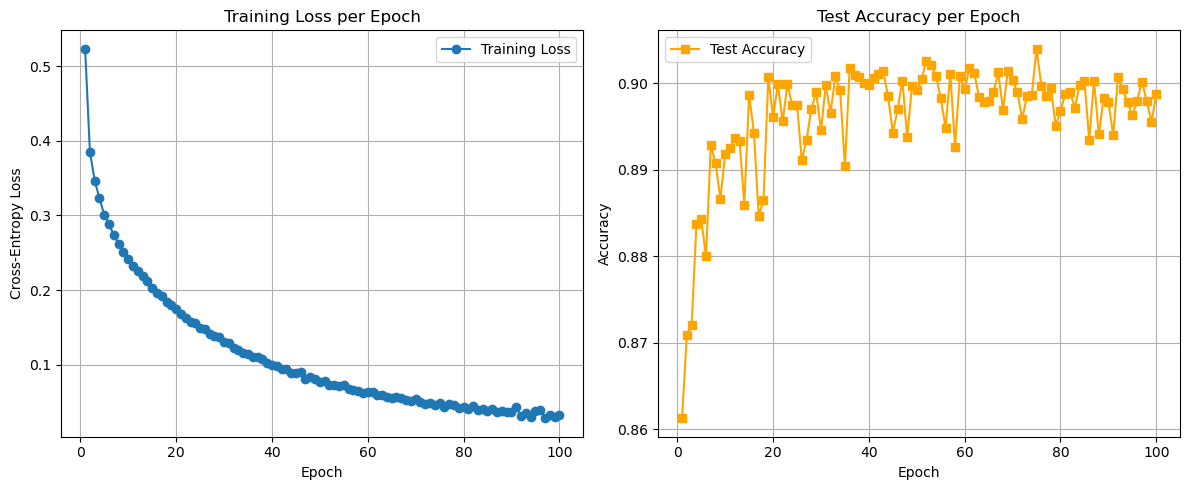

In [15]:
import matplotlib.pyplot as plt

# 设置画布
plt.figure(figsize=(12, 5))

# 1. 绘制 Loss 曲线
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), loss_history, marker='o', label='Training Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.grid(True)
plt.legend()

# 2. 绘制 Accuracy 曲线
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), acc_history, marker='s', color='orange', label='Test Accuracy')
plt.title('Test Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

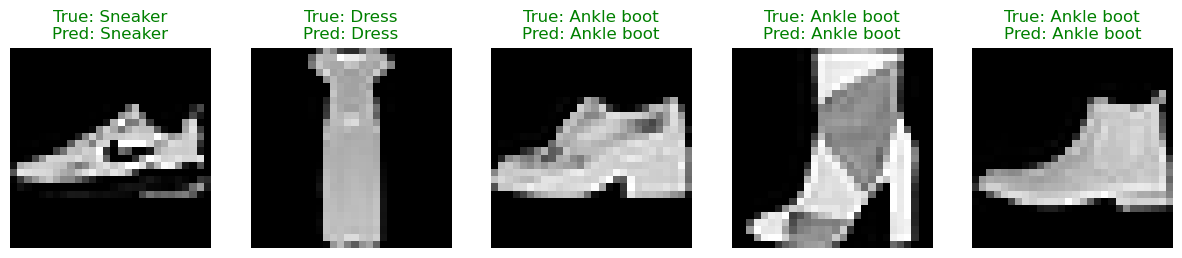

In [16]:
# 类别标签映射表
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 随机选 5 个索引
random_indices = np.random.choice(len(X_test), 5)

plt.figure(figsize=(15, 5))

for i, idx in enumerate(random_indices):
    img = X_test[idx].reshape(28, 28)
    label_true = class_names[np.argmax(y_test[idx])]
    
    # 模型预测
    pred_prob = mlp.forward(X_test[idx:idx+1])
    label_pred = class_names[np.argmax(pred_prob)]
    
    plt.subplot(1, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {label_true}\nPred: {label_pred}", color=('green' if label_true == label_pred else 'red'))
    plt.axis('off')

plt.show()

In [ ]:
def classification_report_manual(y_true, y_pred, class_names):
    # 转换为类别索引
    true_labels = np.argmax(y_true, axis=1)
    pred_labels = np.argmax(y_pred, axis=1)
    
    num_classes = len(class_names)
    # 初始化混淆矩阵
    conf_matrix = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(true_labels, pred_labels):
        conf_matrix[t, p] += 1
    
    print(f"{'Class':<20} | {'Precision':<10} | {'Recall':<10} | {'F1-score':<10}")
    print("-" * 60)
    
    precisions, recalls, f1s = [], [], []
    
    for i in range(num_classes):
        tp = conf_matrix[i, i]
        fp = np.sum(conf_matrix[:, i]) - tp
        fn = np.sum(conf_matrix[i, :]) - tp
        
        # 计算指标，处理分母为0的情况
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        
        print(f"{class_names[i]:<20} | {precision:<10.4f} | {recall:<10.4f} | {f1:<10.4f}")
    
    print("-" * 60)
    print(f"{'Macro Average':<20} | {np.mean(precisions):<10.4f} | {np.mean(recalls):<10.4f} | {np.mean(f1s):<10.4f}")
    
    return conf_matrix

# 定义类别名称
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Class                | Precision  | Recall     | F1-score  
------------------------------------------------------------
T-shirt/top          | 0.8735     | 0.8150     | 0.8432    
Trouser              | 0.9849     | 0.9800     | 0.9825    
Pullover             | 0.8388     | 0.8120     | 0.8252    
Dress                | 0.8815     | 0.9300     | 0.9051    
Coat                 | 0.8471     | 0.8420     | 0.8445    
Sandal               | 0.9915     | 0.9340     | 0.9619    
Shirt                | 0.7291     | 0.7780     | 0.7528    
Sneaker              | 0.9236     | 0.9670     | 0.9448    
Bag                  | 0.9817     | 0.9680     | 0.9748    
Ankle boot           | 0.9497     | 0.9620     | 0.9558    
------------------------------------------------------------
Macro Average        | 0.9002     | 0.8988     | 0.8991    


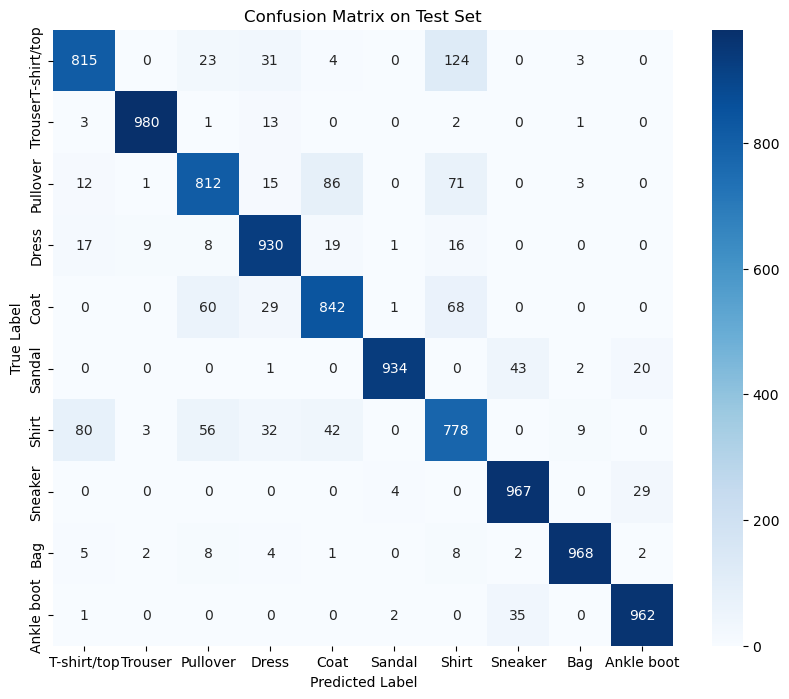

In [18]:
import seaborn as sns # 仅用于绘图展示，不涉及算法调用

# 1. 获取模型在测试集上的预测结果
test_outputs = mlp.forward(X_test)

# 2. 生成详细指标报告
conf_mat = classification_report_manual(y_test, test_outputs, class_names)

# 3. 绘制混淆矩阵热力图
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()